
<center>

# Applying Dimensionality Reduction on the Iris Dataset

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 9 Principal Component Analysis (PCA)
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>

## PCA, t-SNE, and LDA on Iris

PCA with n_components=2
Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Total explained variance: 0.9581320720000166

PCA with 90% variance retained
Original shape: (150, 4)
Reduced shape: (150, 2)
Number of components selected: 2
Explained variance ratio: [0.72962445 0.22850762]
Total explained variance: 0.9581320720000166

t-SNE
Original shape: (150, 4)
Reduced shape: (150, 2)

LDA
Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance ratio: [0.9912126 0.0087874]


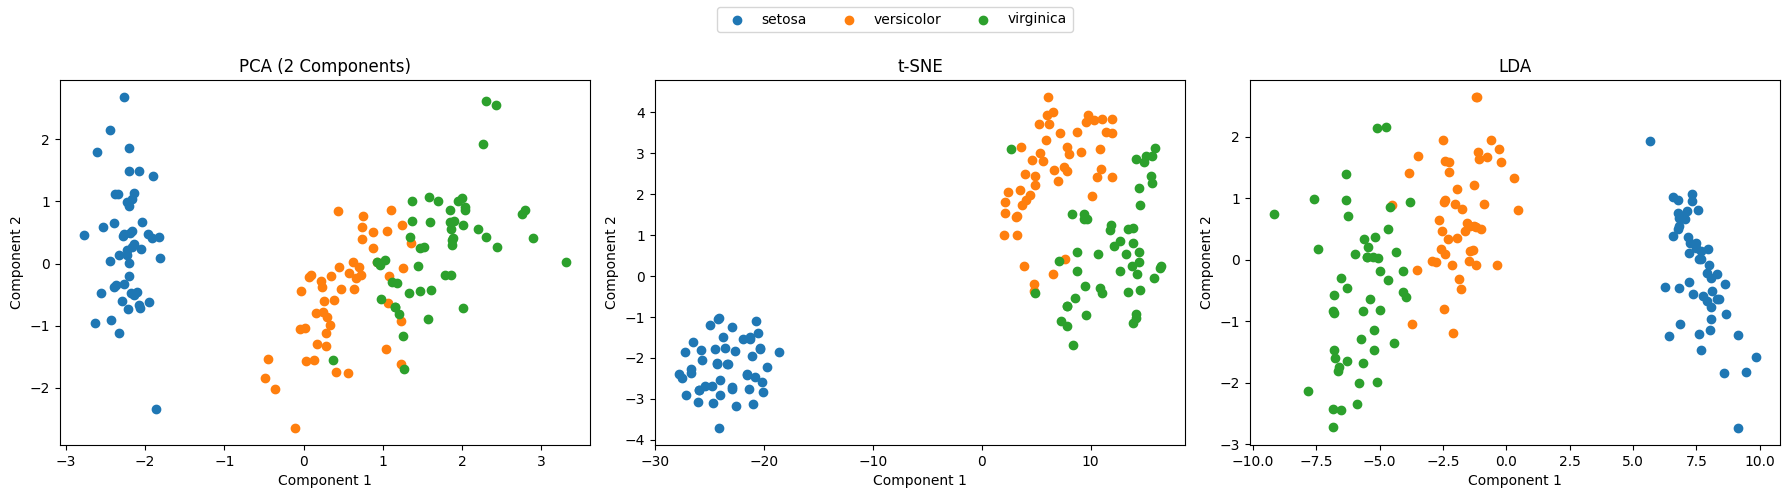

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Load dataset

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names


# 2. Standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3. PCA with fixed components

pca_fixed = PCA(n_components=2)
X_pca_fixed = pca_fixed.fit_transform(X_scaled)

print("PCA with n_components=2")
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_fixed.shape)
print("Explained variance ratio:", pca_fixed.explained_variance_ratio_)
print("Total explained variance:", pca_fixed.explained_variance_ratio_.sum())


# 4. PCA with variance threshold

pca_perc = PCA(0.90)
X_pca_perc = pca_perc.fit_transform(X_scaled)

print("\nPCA with 90% variance retained")
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_perc.shape)
print("Number of components selected:", pca_perc.n_components_)
print("Explained variance ratio:", pca_perc.explained_variance_ratio_)
print("Total explained variance:", pca_perc.explained_variance_ratio_.sum())

# 5. t-SNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("\nt-SNE")
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_tsne.shape)


# 6. LDA

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("\nLDA")
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_lda.shape)
print("Explained variance ratio:", lda.explained_variance_ratio_)


# 7. Put into DataFrames

df_pca = pd.DataFrame(X_pca_fixed, columns=["Comp1", "Comp2"])
df_pca["species"] = [target_names[i] for i in y]

df_tsne = pd.DataFrame(X_tsne, columns=["Comp1", "Comp2"])
df_tsne["species"] = [target_names[i] for i in y]

df_lda = pd.DataFrame(X_lda, columns=["Comp1", "Comp2"])
df_lda["species"] = [target_names[i] for i in y]

# 8. Plot all methods

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA plot
for species in target_names:
    subset = df_pca[df_pca["species"] == species]
    axes[0].scatter(subset["Comp1"], subset["Comp2"], label=species)
axes[0].set_title("PCA (2 Components)")
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")

# t-SNE plot
for species in target_names:
    subset = df_tsne[df_tsne["species"] == species]
    axes[1].scatter(subset["Comp1"], subset["Comp2"], label=species)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")

# LDA plot
for species in target_names:
    subset = df_lda[df_lda["species"] == species]
    axes[2].scatter(subset["Comp1"], subset["Comp2"], label=species)
axes[2].set_title("LDA")
axes[2].set_xlabel("Component 1")
axes[2].set_ylabel("Component 2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Dimensionality Reduction Using Iris Dataset

In this analysis, the Iris dataset was reduced using four approaches:

 a) PCA with a fixed number of components  
 b) PCA with a variance threshold  
 c) t-SNE  
 d) Linear Discriminant Analysis
   
 Before applying these methods, the features were standardized using StandardScaler so that each variable contributed equally to the transformation. PCA was first applied with n_components=2, reducing the four original features to two principal components. A second PCA approach was then applied using PCA(0.90), which automatically selected the minimum number of components required to preserve at least 90% of the variance. Since the first two principal components in Iris explain most of the variability, this approach is also likely to retain two dimensions.

t-SNE was then used to produce a two-dimensional representation of the data. Unlike PCA, t-SNE is a nonlinear dimensionality reduction technique mainly intended for visualization. It focuses on preserving local neighborhood relationships, making it useful for revealing clusters in the dataset.

Finally, Linear Discriminant Analysis was applied. LDA differs from PCA because it is supervised and uses the target labels during transformation. Its goal is not simply to preserve variance, but to maximize class separability. For the Iris dataset, this often results in clearer separation among the flower species than PCA. PCA is useful for variance-based reduction, t-SNE is powerful for visualization of local structure, and LDA is especially useful when class labels are available and the objective is discrimination between groups.